In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="IvoHrO52vGgeETGObPtG")
project = rf.workspace("ampeldetection").project("leagueoflegends")
version = project.version(1)
dataset = version.download("yolov11")


loading Roboflow workspace...
loading Roboflow project...


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.3.240 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 39.1/112.6 GB disk)


In [ ]:
from ultralytics import YOLO

# Load a pretrained model (nano version for speed)
model = YOLO("yolo11n.pt")

In [ ]:
model

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_

In [ ]:
results = model.train(
    data="/content/LeagueOfLegends-1/data.yaml",  # path to dataset YAML
    epochs=23,                 # number of epochs
    imgsz=640,                 # image size
    batch=16,                  # batch size
    project="/content/drive/MyDrive/LOL_CV",     # where to save results
    name="exp1",               # experiment name
    device="0"                 # use GPU 0 (or "cpu")
)

Ultralytics 8.3.240 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/LeagueOfLegends-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=23, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=exp12, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, p

In [ ]:
for key , value in results.results_dict.items():
  print(f"{key} : {value}")


metrics/precision(B) : 0.9295245713236904
metrics/recall(B) : 0.911211067998312
metrics/mAP50(B) : 0.9724571267020704
metrics/mAP50-95(B) : 0.9251287164634948
fitness : 0.9251287164634948


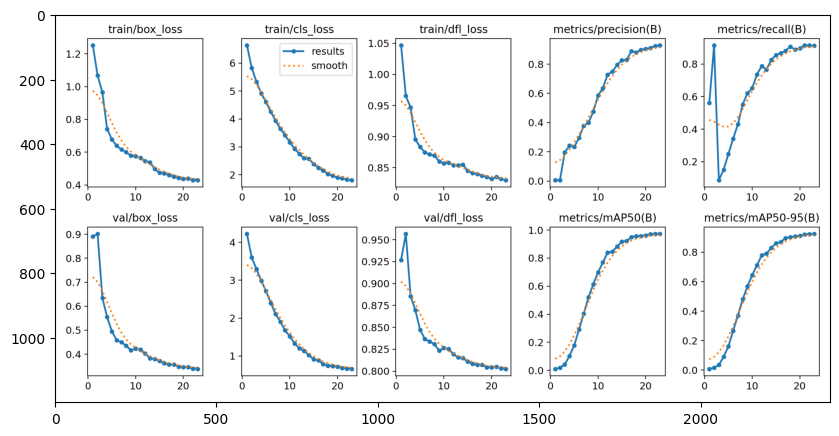

In [ ]:
import matplotlib.pyplot as plt
img = plt.imread("/content/drive/MyDrive/LOL_CV/exp12/results.png")
plt.figure(figsize=(10,10))
plt.imshow(img)

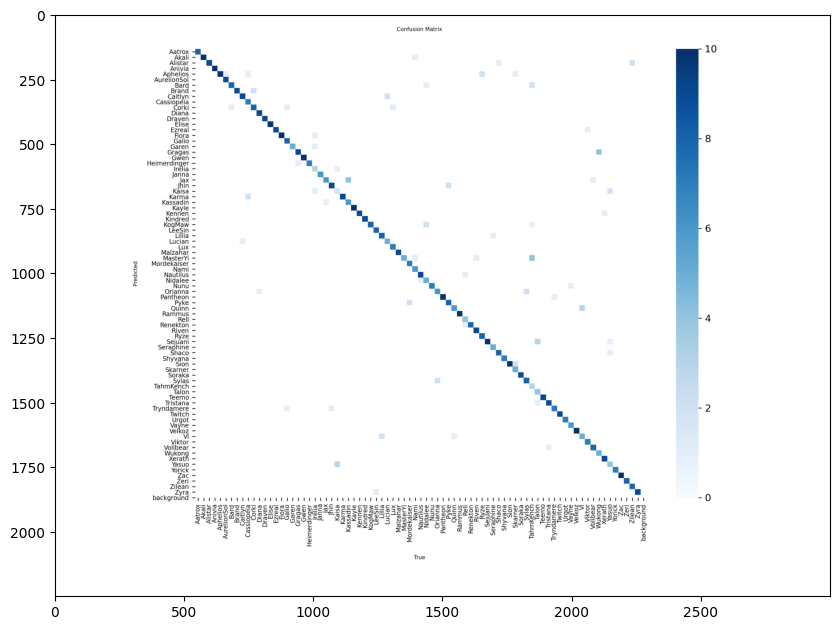

In [ ]:
img = plt.imread("/content/drive/MyDrive/LOL_CV/exp12/confusion_matrix.png")
plt.figure(figsize=(10,10))
plt.imshow(img)

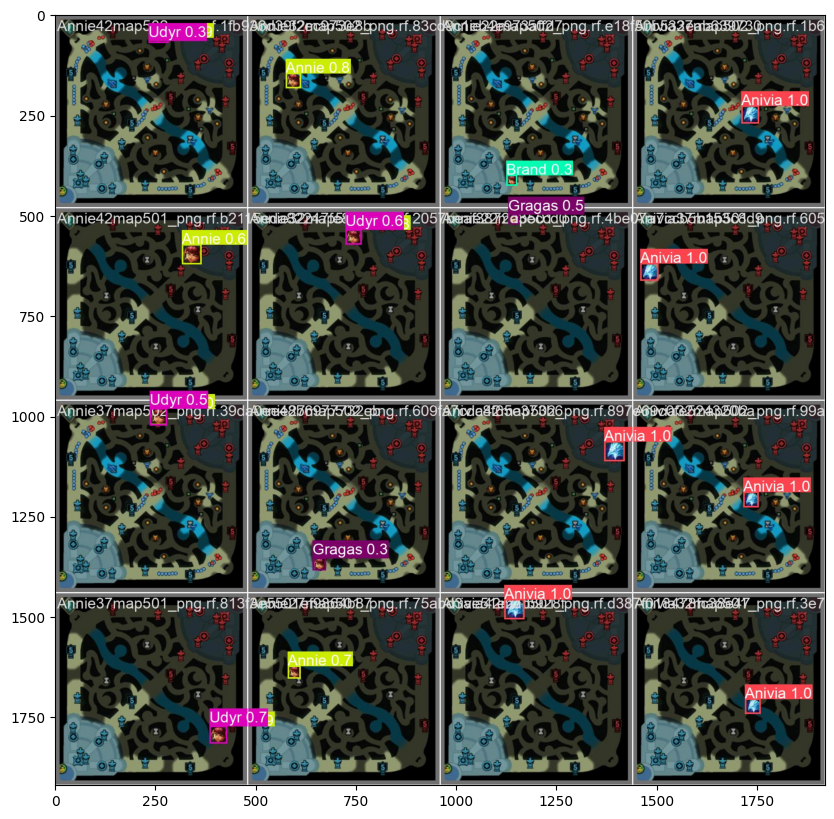

In [ ]:
img = plt.imread("/content/drive/MyDrive/LOL_CV/exp12/val_batch2_pred.jpg")
plt.figure(figsize=(10,10))
plt.imshow(img)

In [ ]:
# Validate the trained model
valid_result = model.val()

Ultralytics 8.3.240 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,665,465 parameters, 0 gradients, 6.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1240.1±459.0 MB/s, size: 25.4 KB)
val: Scanning /content/LeagueOfLegends-1/valid/labels.cache... 1590 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1590/1590 3.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 100/100 6.0it/s 16.7s
                   all       1590       1590       0.93       0.91      0.972      0.927
                Aatrox         10         10      0.883          1      0.995      0.919
                  Ahri         10         10      0.789        0.6      0.798      0.761
                 Akali         10         10      0.973          1      0.995      0.971
                Akshan         10         10          1      0.697      0.869      0.826
               Alistar         